## Case 3 plots and labels inside

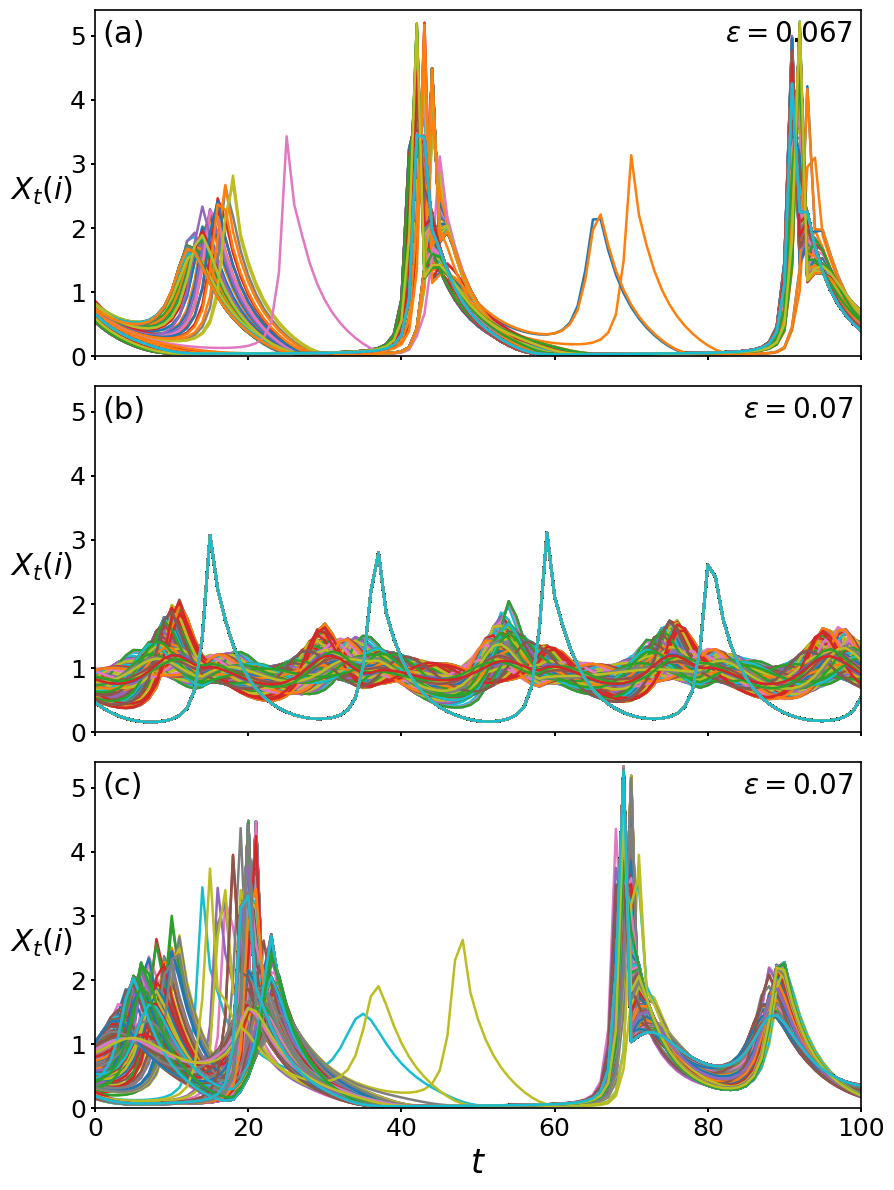

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import numba
from numba import njit, prange

# local dynamics
@njit(parallel=False)
def fx(xold,yold,d):
    fxn=(xold**2)*(np.exp(yold-xold))+d
    return fxn
@njit(parallel=False)
def fy(xold,yold):
    fyn=a*(yold)-q*(xold)+c
    return fyn

#Connections
def xn(fxn):
    xnew = (1-eps)*fxn + eps*np.mean(fxn)    
    return xnew

#Parameters
N = 1000
b= 101
T=50000
a=0.89
q=0.18
c=0.28

#Global Evolution 
def GCM(eps):
    initialx = np.random.uniform(1, 3, N)
    initialy = np.random.uniform(1, 4, N)
    x_s = np.zeros((T,N)) #to do transients 
    y_s = np.zeros((T,N)) #to do transients
    heterogeniety = 0.026
    x_s[0,:] = initialx
    y_s[0,:] = initialy
    for t in range(T-1):
        f_xj = fx(initialx, initialy, heterogeniety)
        f_yj = fy(initialx, initialy)
        x_s[t+1, :]= xn(f_xj)
        y_s[t+1, :]= f_yj
        initialx = x_s[t+1, :]
        initialy = y_s[t+1, :]
    return x_s



eps_values = [0.067, 0.07, 0.07]
labels = ['(a)', '(b)', '(c)']

time = np.arange(0, b, 1)

fig, axes = plt.subplots(3, 1, figsize=(9, 12), sharex=True)

for idx, eps_val in enumerate(eps_values):

    eps = eps_val
    states = GCM(eps)

    S_matrix = np.zeros((b, N))
    for tiempo in range(0, b):
        S_matrix[tiempo] = states[T-b+tiempo]

    ax = axes[idx]

    for ij in range(N):
        ax.plot(time, S_matrix[:, ij], linewidth=1.8)

    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(1.2)
        ax.spines[axis].set_edgecolor('black')

    ax.tick_params(axis='both', which='major', labelsize=18, width=1.4, length=3)
    ax.set_ylim(0, 5.4)
    ax.set_xlim(0, 100)
    ax.grid(False)

    # (a), (b), (c) labels
    ax.text(0.01, 0.97, labels[idx],
            transform=ax.transAxes,
            fontsize=22,
            va='top',
            ha='left')

    # eps labels
    ax.text(0.99, 0.97, rf"$\varepsilon = {eps_val}$",
            transform=ax.transAxes,
            fontsize=20,
            va='top',
            ha='right')


    ax.set_ylabel(r"$X_t(i)$", fontsize=22, rotation=0, labelpad=18)
    ax.yaxis.set_label_coords(-0.07, 0.43)

axes[-1].set_xlabel(r"$t$", fontsize=24)

plt.tight_layout()
plt.savefig("Fig1_timeseries.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()



In [25]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import numba
from numba import njit

# local dynamics
@njit(parallel=False)
def fx(xold, yold, d):
    return (xold**2) * np.exp(yold - xold) + d

@njit(parallel=False)
def fy(xold, yold):
    return a * yold - q * xold + c

# Connections
def xn(fxn):
    return (1 - eps) * fxn + eps * np.mean(fxn)

# Parameters
N = 1000
b = 101
T = 50000
a = 0.89
q = 0.18
c = 0.28

# Global Evolution
def GCM(eps):
    initialx = np.random.uniform(1, 3, N)
    initialy = np.random.uniform(1, 4, N)

    x_s = np.zeros((T, N))
    y_s = np.zeros((T, N))

    heterogeniety = np.random.uniform(0.026, 0.03, N)

    x_s[0, :] = initialx
    y_s[0, :] = initialy

    for t in range(T - 1):
        f_xj = fx(initialx, initialy, heterogeniety)
        f_yj = fy(initialx, initialy)

        x_s[t + 1, :] = xn(f_xj)
        y_s[t + 1, :] = f_yj

        initialx = x_s[t + 1, :]
        initialy = y_s[t + 1, :]

    return x_s


# ---- plotting ----
eps_values = [0.12, 0.13, 0.11]
labels = ['(b)', '(b)', '(b)']
time = np.arange(0, b, 1)

for idx, eps_val in enumerate(eps_values):

    eps = eps_val
    states = GCM(eps)

    S_matrix = np.zeros((b, N))
    for t in range(b):
        S_matrix[t] = states[T - b + t]

    # Figura individual
    fig, ax = plt.subplots(figsize=(9, 4.2))

    for ij in range(N):
        ax.plot(time, S_matrix[:, ij], linewidth=1.8)

    # Estilo idéntico
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(1.2)
        ax.spines[axis].set_edgecolor('black')

    ax.tick_params(axis='both', which='major',
                   labelsize=14, width=1.4, length=3)

    ax.set_ylim(0, 5.3)
    ax.set_xlim(0, 100)
    ax.grid(False)

    # Labels internos
    ax.text(0.01, 0.97, labels[idx],
            transform=ax.transAxes,
            fontsize=19,
            va='top',
            ha='left')

    ax.set_ylabel(r"$x_t(i)$", fontsize=20,
                  rotation=0, labelpad=18)
    ax.yaxis.set_label_coords(-0.07, 0.43)

    ax.set_xlabel(r"$t$", fontsize=20)

    plt.tight_layout()
    plt.savefig(f"Fig1_timeseries_eps_{eps_val}.pdf",
                format="pdf", dpi=300, bbox_inches="tight")
    plt.close()
